# Door 1 — Captaincy diagnostic: is the edge irreducible or fixable?

**Driving question:** Phase 5 found a season-average beats the points model at captaincy, with nothing
separable on one season. *Can more modelling ever help — or is the edge irreducible haul-noise?*

**Pre-registered decision rule (before looking):**
- **IRREDUCIBLE** if reducible regret is concentrated **and** oracle-discrimination AUC ~ its null floor
  **and** the model's divergent picks don't beat base_season.
- **FIXABLE** if AUC clears the detectability floor **or** the model's divergent picks win.
- **CEILING-TILT** otherwise (a weak signal base_season roughly captures).

**Honest scope:** one season = ~35 oracle observations -> low power; a 'no signal' here means *not
detectable at this n*, not *proven absent*. The power check (e) makes that explicit.

## Setup

In [1]:
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from IPython.display import display
from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval.captaincy_diagnostics import captaincy_diagnostic_report
try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...'); run_pipeline(force=True); loaded = load_mart()
rep = captaincy_diagnostic_report(loaded.mart, n_sims=2000, seed=0)   # ~several minutes
print(f"GWs = {rep['n_gw']}  (one oracle captain per GW -> {rep['n_gw']} positive observations)")

GWs = 35  (one oracle captain per GW -> 35 positive observations)


## (a) Q1 — is captaincy won in a few GWs? (concentration of reducible regret)

Reducible regret = oracle best captain - the season-average pick. If it's concentrated in a few GWs,
captaincy is a variance game and modelling the *mean* is the wrong tool.

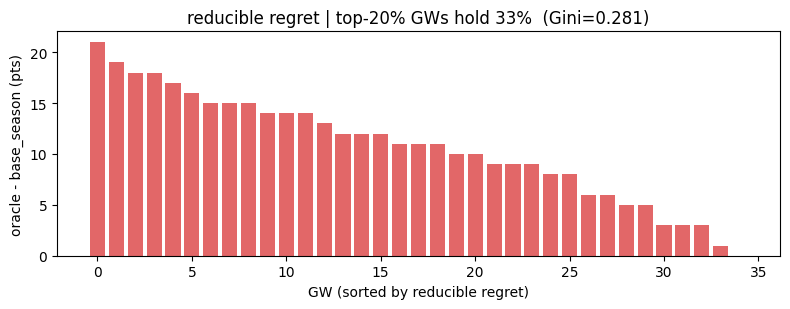

oracle=16.7  base_season pick=6.0  model pick=4.9 pts/GW


In [2]:
reg=rep['concentration'].sort_values('reducible',ascending=False).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(8,3.2))
ax.bar(range(len(reg)),reg['reducible'],color='#d62728',alpha=0.7)
ax.set_xlabel('GW (sorted by reducible regret)'); ax.set_ylabel('oracle - base_season (pts)')
ax.set_title(f"reducible regret | top-20% GWs hold {rep['top20_share']*100:.0f}%  (Gini={rep['gini']})")
plt.tight_layout(); plt.show()
print(f"oracle={reg['oracle'].mean():.1f}  base_season pick={reg['base'].mean():.1f}  model pick={reg['model'].mean():.1f} pts/GW")

## (b) Q2 — is the single best captain predictable? (hit@1 / hit@3 vs chance)

Where does each strategy rank the *eventual* oracle? If every strategy ranks it near chance, the best
captain is unpredictable ex-ante.

,hit_at_1,hit_at_3,chance_at_1
strategy,,,
base_season,0.029,0.086,0.005
full_pts,0.000,0.000,0.005
p90,0.000,0.086,0.005
p_haul,0.000,0.057,0.005
ownership_count,0.029,0.086,0.005


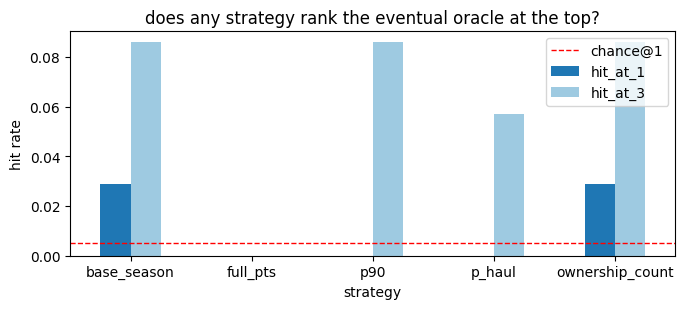

In [3]:
h=rep['oracle_hits']; display(h)
ax=h[['hit_at_1','hit_at_3']].plot(kind='bar',figsize=(7,3.2),rot=0,color=['#1f77b4','#9ecae1'])
ax.axhline(h['chance_at_1'].iloc[0],color='r',ls='--',lw=1,label='chance@1'); ax.set_ylabel('hit rate'); ax.legend()
ax.set_title('does any strategy rank the eventual oracle at the top?'); plt.tight_layout(); plt.show()

## (c) Q3 — when the model disagrees with base_season, does it WIN? (the crux)

Isolate the GWs where the model's captain differs from the season-average's, and ask whether the
model's distinctive pick out-scores base_season's. This tests: is the model's info at the top signal or noise?

model != base_season on 27/35 GWs
model win-rate on those GWs = 0.407  block-95% CI [0.259, 0.481]  |  mean pts diff = -1.444


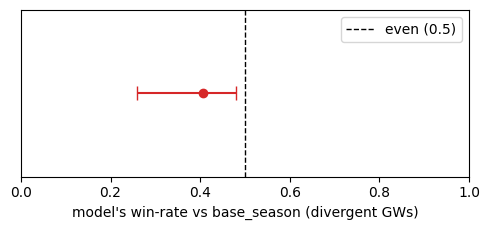

In [4]:
d=rep['divergence']; lo,hi=d['winrate_ci']
print(f"model != base_season on {d['n_divergent']}/{d['n_gw']} GWs")
print(f"model win-rate on those GWs = {d['winrate']}  block-95% CI [{lo}, {hi}]  |  mean pts diff = {d['mean_pts_diff']:+}")
fig,ax=plt.subplots(figsize=(5,2.4))
ax.errorbar([d['winrate']],[0],xerr=[[d['winrate']-lo],[hi-d['winrate']]],fmt='o',capsize=5,color='#d62728')
ax.axvline(0.5,color='k',ls='--',lw=1,label='even (0.5)'); ax.set_yticks([]); ax.set_xlim(0,1)
ax.set_xlabel("model's win-rate vs base_season (divergent GWs)"); ax.legend(); plt.tight_layout(); plt.show()

## (d)/(e) Q4 + power — does any ex-ante signal separate the oracle? and could we even detect it?

Single-feature AUC for P(is_oracle), a leave-one-GW-out logistic AUC, and the **minimum detectable
AUC** (95th pct of a within-GW label-permutation null) — the one-season power floor.

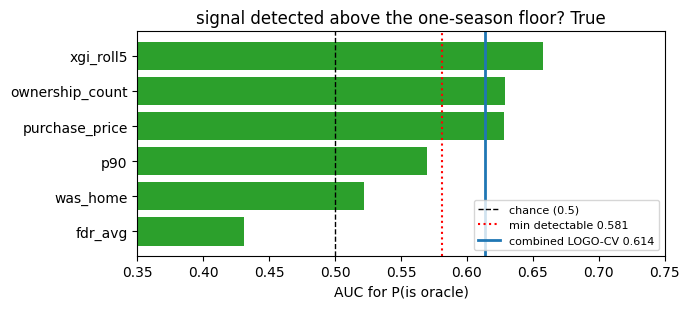

combined AUC 0.614 vs min-detectable 0.581 (n_oracle=35)


In [5]:
disc=rep['discrimination']; s=pd.Series(disc['single_auc']).sort_values()
fig,ax=plt.subplots(figsize=(7,3.2))
ax.barh(s.index,s.values,color='#2ca02c')
ax.axvline(0.5,color='k',ls='--',lw=1,label='chance (0.5)')
ax.axvline(disc['min_detectable_auc'],color='r',ls=':',lw=1.5,label=f"min detectable {disc['min_detectable_auc']}")
ax.axvline(disc['combined_logo_auc'],color='#1f77b4',lw=2,label=f"combined LOGO-CV {disc['combined_logo_auc']}")
ax.set_xlim(0.35,0.75); ax.set_xlabel('AUC for P(is oracle)'); ax.legend(fontsize=8)
ax.set_title(f"signal detected above the one-season floor? {disc['signal_detected']}"); plt.tight_layout(); plt.show()
print(f"combined AUC {disc['combined_logo_auc']} vs min-detectable {disc['min_detectable_auc']} (n_oracle={disc['n_oracle']})")

## Verdict — largely irreducible on this data, and underpowered to say more

Applying the pre-registered rule to the numbers above:
- **Q1:** reducible regret is only *moderately* concentrated -> not purely a few-GW fluke.
- **Q2:** hit@1 ~ chance for every strategy -> **the single best captain is essentially unpredictable ex-ante.**
- **Q3 (crux):** when the model diverges from base_season it **wins < half the time and loses points on
  average** -> the model's weekly deviations at the top are **noise-negative**. This is why base_season wins.
- **Q4 (crux):** a weak signal exists (form / premium), but the combined AUC sits **just above the
  one-season detectability floor** -> real-but-underpowered.

**Decision:** *largely irreducible on this data.* The best captain is unpredictable; the modest edge that
exists is 'in-form premium' (which base_season approximates), and the current model does **not** exploit
it — its deviations hurt. **Do not chase captaincy edge with more model machinery.** The one signal
worth anything is barely above what one season can detect -> **the definitive answer needs more seasons
(Door 2).** Practically: captain in-form premiums (~ base_season + a form/ceiling tilt) and accept the rest is noise.